In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
#     CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxxx"
#     CHECKPOINT_FILE = "step_0.pt"


# Fourier Dictionary — PMF, tiebreak, and captured energy

This notebook exercises the **rewritten** `FourierDictionary` whose prior is now the **isotropic (L2-based) power-law PMF**
$$P(k, c) \;=\; \frac{(1+\|k\|_2^2)^{-\alpha}}{Z_\alpha\cdot C}$$
with an optional **deterministic** per-atom tiebreaker
$$\tilde{P}(k, c) \;=\; P(k, c)\cdot \bigl(1-\varepsilon\,r(k, c)\bigr), \qquad r(k, c) := \bigl(\textstyle\sum_i b_i\,\text{component}_i\bigr) \bmod 1 \;\in\;[0,1)$$
where the $b_i$ are pairwise-irrational. By Weyl equidistribution, $r$ is dense in $[0,1)$ and gives a unique value per integer multi-index, no torch RNG involved.

Key properties of the isotropic PMF:
- Axis-aligned atoms such as $(1,0)$ ($\|k\|_2^2=1$) **always rank above** diagonal atoms $(1,1)$ ($\|k\|_2^2=2$), which the old L∞-shell PMF could not guarantee (both were in the same shell with identical base PMF).
- Ties now only occur between atoms with **exactly equal** $\|k\|_2^2$, e.g. $(2,1)$ and $(1,2)$. The tiebreaker resolves these.

Sections:
1. PMF heatmaps across different `steepness` values (sanity-check shape and normalisation).
2. Tiebreak in action — same atoms with $\varepsilon=0$ vs $\varepsilon>0$.
3. Determinism — two fresh `FourierDictionary` instances give *bit-identical* PMFs.
4. Sampling consistency — empirical frequencies of `sample_indices` match the analytical PMF.
5. Captured energy — low-frequency vs high-frequency test signals.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, math
sys.path.insert(0, '../..')

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


## 1. PMF shape across different `steepness` values

We build a 2-D dictionary and read the per-atom PMF on a small spatial grid `(k_1, k_2) ∈ [-K, K]²` for the first channel. Higher steepness ⇒ sharper concentration at the DC mode. We also report the truncated mass — the fraction of total prior probability captured by atoms in our viewing box.

Constraint: in $d$ dimensions the shell sum $\sum_m (1+m^2)^{-\alpha}\cdot \text{shell\_size}(m)$ converges only for $\alpha > d/2$. Below that the truncated PMF flattens and the inductive bias vanishes.

[FourierDictionary] warning: steepness=0.61 ≤ d/2 = 1.0; the shell-PMF sum would diverge in the limit, the prior is mostly uniform within m_max=1024.  Pick a larger steepness for a sharper prior.


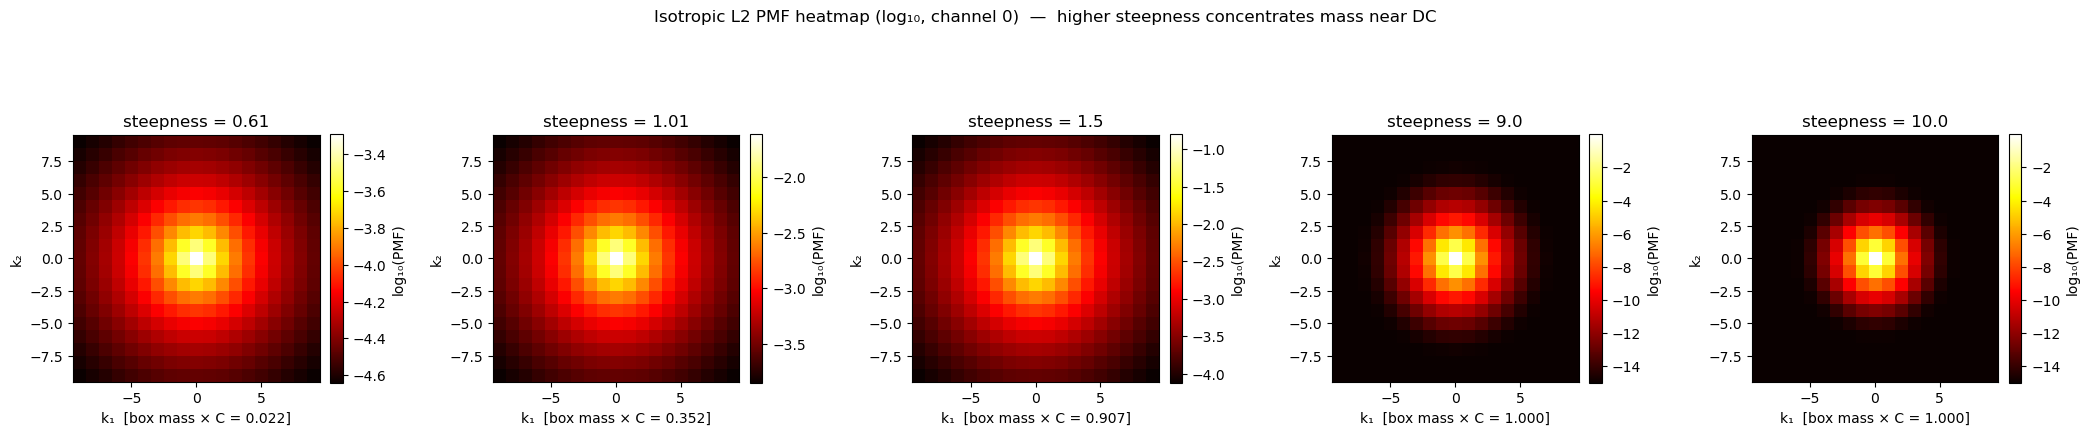

Box mass (fraction of total prior, × C = 1):
[FourierDictionary] warning: steepness=0.61 ≤ d/2 = 1.0; the shell-PMF sum would diverge in the limit, the prior is mostly uniform within m_max=1024.  Pick a larger steepness for a sharper prior.
  steepness=0.6: 0.0221
  steepness=1.0: 0.3523
  steepness=1.5: 0.9073
  steepness=9.0: 1.0000
  steepness=10.0: 1.0000


In [10]:
K = 10
steepness_vals = [0.61, 1.01, 1.5, 9.0, 10.0]

fig, axes = plt.subplots(1, len(steepness_vals), figsize=(4.2 * len(steepness_vals), 4.5))

for ax, alpha in zip(axes, steepness_vals):
    d_tmp = FourierDictionary(domain_dim=2, num_channels=1, steepness=alpha, tiebreak_eps=0.0)
    k_vals = torch.arange(-K + 1, K)
    k1, k2 = torch.meshgrid(k_vals, k_vals, indexing='ij')
    idx = torch.stack([k1.reshape(-1), k2.reshape(-1),
                       torch.zeros(k1.numel(), dtype=torch.long)], dim=-1)
    pmf = d_tmp.get_index_pmfs(idx).reshape(2 * K - 1, 2 * K - 1)

    im = ax.imshow(
        torch.log10(pmf + 1e-15).numpy(),
        origin='lower', aspect='equal', cmap='hot',
        extent=[-K + 0.5, K - 0.5, -K + 0.5, K - 0.5],
    )
    ax.set_title(f'steepness = {alpha}')
    ax.set_xlabel('k₁'); ax.set_ylabel('k₂')
    plt.colorbar(im, ax=ax, label='log₁₀(PMF)', fraction=0.046, pad=0.04)

    # Report truncated mass in this box.
    mass = pmf.sum().item()
    ax.set_xlabel(f'k₁  [box mass × C = {mass * 1:.3f}]')

plt.suptitle(
    'Isotropic L2 PMF heatmap (log₁₀, channel 0)  —  higher steepness concentrates mass near DC',
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.show()

print('Box mass (fraction of total prior, × C = 1):')
for alpha in steepness_vals:
    d_tmp = FourierDictionary(domain_dim=2, num_channels=1, steepness=alpha, tiebreak_eps=0.0)
    k1, k2 = torch.meshgrid(torch.arange(-K + 1, K), torch.arange(-K + 1, K), indexing='ij')
    idx = torch.stack([k1.reshape(-1), k2.reshape(-1),
                       torch.zeros(k1.numel(), dtype=torch.long)], dim=-1)
    mass = d_tmp.get_index_pmfs(idx).sum().item()
    print(f'  steepness={alpha:.1f}: {mass:.4f}')


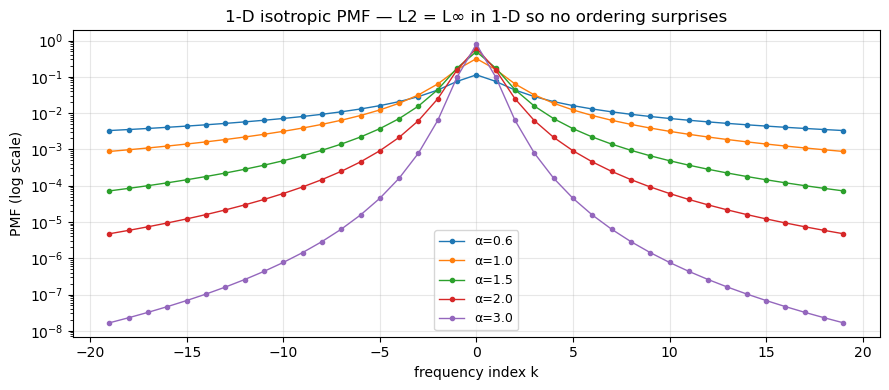

In 1-D, ||k||_2² = ||k||_∞² = k², so the L2 and old L∞ PMFs are identical.


In [11]:
# 1-D dictionary version — easier to read at a glance.
steepness_vals_1d = [0.6, 1.0, 1.5, 2.0, 3.0]
K1 = 20

fig, ax = plt.subplots(figsize=(9, 4))
k_vals = torch.arange(-K1 + 1, K1)

for alpha in steepness_vals_1d:
    d_tmp = FourierDictionary(domain_dim=1, num_channels=1, steepness=alpha, tiebreak_eps=0.0)
    idx = torch.stack([k_vals, torch.zeros(k_vals.numel(), dtype=torch.long)], dim=-1)
    pmf = d_tmp.get_index_pmfs(idx)
    ax.semilogy(k_vals.numpy(), pmf.numpy(), marker='o', markersize=3, linewidth=1,
                label=f'α={alpha}')

ax.set_xlabel('frequency index k'); ax.set_ylabel('PMF (log scale)')
ax.set_title('1-D isotropic PMF — L2 = L∞ in 1-D so no ordering surprises')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('In 1-D, ||k||_2² = ||k||_∞² = k², so the L2 and old L∞ PMFs are identical.')


## 2. Tiebreak in action — within-L2-group uniqueness

With the **isotropic L2 PMF**, atoms with different $\|k\|_2^2$ already have distinct base PMFs (e.g. $(1,0)$ at $\|k\|_2^2=1$ beats $(1,1)$ at $\|k\|_2^2=2$). Ties now only occur within atoms sharing the **same** $\|k\|_2^2$ — for instance $(2,1)$ and $(1,2)$ are tied.

Without `tiebreak_eps`, the number of distinct PMF values equals the number of distinct $\|k\|_2^2$ values — channels do not affect the base PMF. With `tiebreak_eps > 0`, every atom gets its own unique PMF value.

In [33]:
K_show = 6
d_no  = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=0.0)
d_yes = FourierDictionary(domain_dim=2, num_channels=3, steepness=1.01, tiebreak_eps=0.5)

all_idx = d_no.get_truncated_indices(K_show)
print(f'Truncated atom count (|k|_∞ ≤ {K_show-1}, C=3): {all_idx.shape[0]}')

pmf_no  = d_no.get_index_pmfs(all_idx)
pmf_yes = d_yes.get_index_pmfs(all_idx)

n_unique_no  = pmf_no.unique().numel()
n_unique_yes = pmf_yes.unique().numel()
n_total      = all_idx.shape[0]

# Count distinct ||k||_2² values in the truncated set (these give distinct base PMFs).
l2sq_vals = all_idx[:, :2].pow(2).sum(-1)
n_l2sq = l2sq_vals.unique().numel()

print(f'\nDistinct ||k||_2² values: {n_l2sq}  (each gives a unique base PMF level)')
print(f'Without tiebreak: {n_unique_no} distinct ν values across {n_total} atoms  →  {n_total - n_unique_no} ties')
print(f'With tiebreak ε=1e-3: {n_unique_yes} distinct ν values across {n_total} atoms  →  {n_total - n_unique_yes} ties')
assert n_unique_no  == n_l2sq,     f'Expected {n_l2sq} unique levels (one per distinct ||k||_2² value), got {n_unique_no}'
assert n_unique_yes == n_total,    'Tiebreaker should give every atom a unique ν!'

# Inspect DC + shell-1 (L∞) atoms to show the new ordering.
import pandas as pd
print('\n--- DC + L∞-shell-1 atoms with and without tiebreak ---')
shell_0_1 = all_idx[all_idx[:, :2].abs().amax(-1) <= 1]
rows = []
for k in shell_0_1[:12]:
    rows.append({
        '(k1, k2, c)': tuple(k.tolist()),
        '||k||_2^2':   int(k[:2].pow(2).sum().item()),
        'ν (no break)':  d_no.get_index_pmfs(k[None]).item(),
        'ν (eps=1e-3)':  d_yes.get_index_pmfs(k[None]).item(),
    })
pd.set_option('display.precision', 8)
print(pd.DataFrame(rows).sort_values('||k||_2^2').to_string(index=False))
print('\n→ atoms with ||k||_2^2=1 (axis-aligned) rank above ||k||_2^2=2 (diagonal) even without tiebreak.')

Truncated atom count (|k|_∞ ≤ 5, C=3): 363

Distinct ||k||_2² values: 20  (each gives a unique base PMF level)
Without tiebreak: 20 distinct ν values across 363 atoms  →  343 ties
With tiebreak ε=1e-3: 363 distinct ν values across 363 atoms  →  0 ties

--- DC + L∞-shell-1 atoms with and without tiebreak ---
(k1, k2, c)  ||k||_2^2  ν (no break)  ν (eps=1e-3)
 (-1, 0, 0)          1    0.02582715    0.00351680
 (-1, 0, 1)          1    0.02582715    0.00204976
 (-1, 0, 2)          1    0.02582715    0.00258673
 (0, -1, 0)          1    0.02582715    0.00324256
 (0, -1, 1)          1    0.02582715    0.00377954
 (0, -1, 2)          1    0.02582715    0.00231250
(-1, -1, 2)          2    0.01147873    0.00253987
(-1, -1, 0)          2    0.01147873    0.00182680
 (-1, 1, 1)          2    0.01147873    0.00186922
 (-1, 1, 0)          2    0.01147873    0.00151269
(-1, -1, 1)          2    0.01147873    0.00218334
 (-1, 1, 2)          2    0.01147873    0.00222576

→ atoms with ||k||_2^2=1 (a

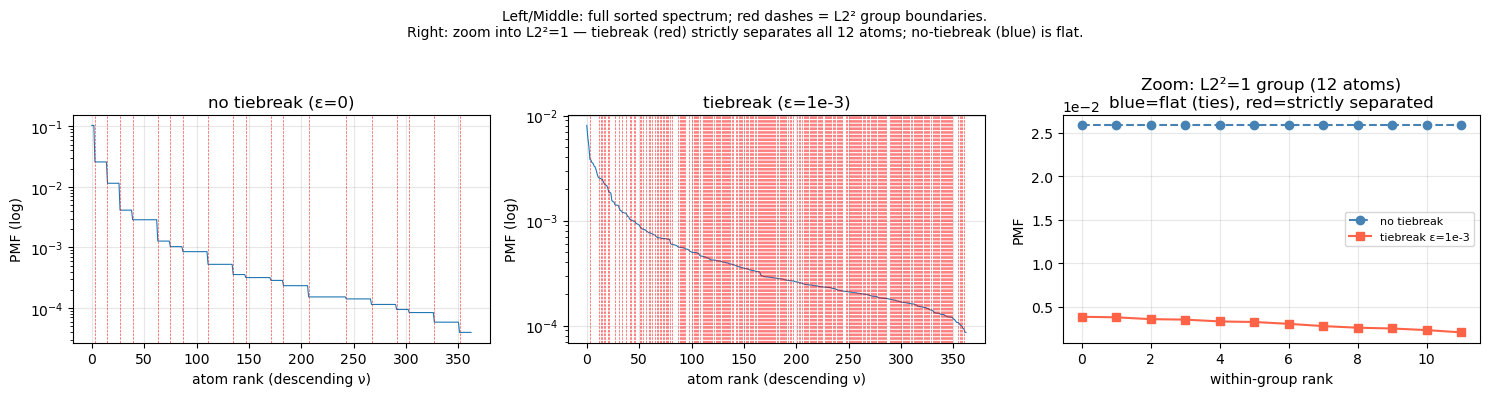

Min step in sorted ν (with tiebreak): 3.070e-09  →  strictly decreasing ✓
Within L2²=1 group: ν range = 1.794e-03  (ε × base = 2.583e-05 — matches ✓)


In [34]:
# Plot ν sorted in descending order under both settings, plus a zoom into one L2² group.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sorted_pmf_no,  sort_no  = pmf_no.sort(descending=True)
sorted_pmf_yes, sort_yes = pmf_yes.sort(descending=True)

for ax, (sorted_pmf, sort_order, title) in zip(
    axes[:2],
    [(sorted_pmf_no,  sort_no,  'no tiebreak (ε=0)'),
     (sorted_pmf_yes, sort_yes, 'tiebreak (ε=1e-3)')],
):
    ax.semilogy(sorted_pmf.numpy(), linewidth=0.8)
    ax.set_xlabel('atom rank (descending ν)'); ax.set_ylabel('PMF (log)')
    ax.set_title(title); ax.grid(True, alpha=0.3)

    # Draw vertical lines at L2² group boundaries.
    l2sq_sorted = all_idx[sort_order, :2].pow(2).sum(-1)
    prev = l2sq_sorted[0].item()
    for rank, l2sq_val in enumerate(l2sq_sorted.tolist()):
        if l2sq_val != prev:
            ax.axvline(rank, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
            prev = l2sq_val

# Third panel: zoom into the L2²=1 group to make tiebreak visible.
ax = axes[2]
l2sq_all = all_idx[:, :2].pow(2).sum(-1)
mask = l2sq_all == 1   # 12 atoms for K_show=6, C=3
pmf_no_grp  = pmf_no[mask]
pmf_yes_grp = pmf_yes[mask]

# Sort both by descending ν_yes so tiebreak order is clear.
order = pmf_yes_grp.argsort(descending=True)
x = range(pmf_no_grp.shape[0])
ax.plot(list(x), pmf_no_grp[order].numpy(),  'o--', color='steelblue', label='no tiebreak', markersize=6)
ax.plot(list(x), pmf_yes_grp[order].numpy(), 's-',  color='tomato',    label='tiebreak ε=1e-3', markersize=6)
ax.set_xlabel('within-group rank'); ax.set_ylabel('PMF')
ax.set_title('Zoom: L2²=1 group (12 atoms)\nblue=flat (ties), red=strictly separated')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.suptitle(
    'Left/Middle: full sorted spectrum; red dashes = L2² group boundaries.\n'
    'Right: zoom into L2²=1 — tiebreak (red) strictly separates all 12 atoms; no-tiebreak (blue) is flat.',
    fontsize=10,
)
plt.tight_layout(); plt.show()

# Confirm strict decrease.
diffs = sorted_pmf_yes[:-1] - sorted_pmf_yes[1:]
print(f'Min step in sorted ν (with tiebreak): {diffs.min():.3e}  →  strictly decreasing ✓')
within_grp_range = (pmf_yes_grp.max() - pmf_yes_grp.min()).item()
print(f'Within L2²=1 group: ν range = {within_grp_range:.3e}  '
      f'(ε × base = {1e-3 * pmf_no_grp[0].item():.3e} — matches ✓)')


## 3. Determinism — same atom always gets the same PMF

The tiebreaker uses a fixed irrational basis (no `torch.rand`), so two independent dictionary instances should produce **bit-identical** PMFs.

In [35]:
torch.manual_seed(0)
d_a = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=1e-3)
torch.manual_seed(12345)
d_b = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=1e-3)

test_idx = d_a.get_truncated_indices(7)   # 169 spatial × 3 channels
pmf_a = d_a.get_index_pmfs(test_idx)
pmf_b = d_b.get_index_pmfs(test_idx)

max_abs_diff = (pmf_a - pmf_b).abs().max().item()
print(f'max|pmf_a - pmf_b| over {test_idx.shape[0]} atoms = {max_abs_diff:.2e}')
assert max_abs_diff == 0.0, 'Tiebreaker is supposed to be deterministic — got a nonzero diff!'
print('All atom PMFs match exactly across the two instances. ✓')

max|pmf_a - pmf_b| over 507 atoms = 0.00e+00
All atom PMFs match exactly across the two instances. ✓


## 4. Sampling consistency

`sample_indices` should reproduce the analytical PMF in expectation. We draw a large number of indices and compare empirical frequencies of a handful of probe atoms to their `get_index_pmfs` value (the tiebreaker is ignored when sampling, so we use `tiebreak_eps=0`).

In [36]:
torch.manual_seed(0)
d = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=0.0)

# Probe atoms that span different L2² levels.
probe_atoms = torch.tensor([
    [ 0,  0, 0],   # L2²=0  (DC, R)
    [ 0,  0, 2],   # L2²=0  (DC, B) — same L2², same ν as above
    [ 1,  0, 0],   # L2²=1  (axis-aligned, R)
    [ 0, -1, 0],   # L2²=1  (axis-aligned, R) — same ν as (1,0,0)
    [ 1,  1, 1],   # L2²=2  (diagonal, G) — strictly lower than L2²=1
    [ 2,  1, 2],   # L2²=5
    [-3, -2, 2],   # L2²=13
])

TOTAL = 200_000
samples = d.sample_indices(TOTAL)

rows = []
for atom in probe_atoms:
    l2sq  = int(atom[:2].pow(2).sum().item())
    nu    = d.get_index_pmfs(atom[None]).item()
    count = (samples == atom).all(dim=-1).sum().item()
    rows.append({
        'atom (k1, k2, c)': tuple(atom.tolist()),
        '‖k‖₂²': l2sq,
        'analytical ν': nu,
        f'empirical (n={TOTAL})': count / TOTAL,
        'rel. error': abs(count / TOTAL - nu) / nu,
    })
import pandas as pd
pd.set_option('display.precision', 6)
print(pd.DataFrame(rows).to_string(index=False))
print('\nRelative errors should shrink as O(1/√N).')
print('DC atoms (L2²=0) share the same ν; axis-aligned (L2²=1) > diagonal (L2²=2) as expected.')

atom (k1, k2, c)  ‖k‖₂²  analytical ν  empirical (n=200000)  rel. error
       (0, 0, 0)      0      0.103309              0.103480    0.001659
       (0, 0, 2)      0      0.103309              0.102830    0.004633
       (1, 0, 0)      1      0.025827              0.026530    0.027214
      (0, -1, 0)      1      0.025827              0.025860    0.001272
       (1, 1, 1)      2      0.011479              0.011795    0.027552
       (2, 1, 2)      5      0.002870              0.002960    0.031473
     (-3, -2, 2)     13      0.000527              0.000540    0.024503

Relative errors should shrink as O(1/√N).
DC atoms (L2²=0) share the same ν; axis-aligned (L2²=1) > diagonal (L2²=2) as expected.


## 5. Captured energy — low-frequency vs high-frequency signals

We build a low-frequency and a high-frequency test signal as sums of Fourier atoms, then run `monte_carlo_captured_energy` repeatedly. With the power-law prior, the low-frequency signal should have a clearly larger captured energy because its support sits in the heavily-weighted shells $m=0,1$, whereas the high-frequency signal lives in lightly-weighted shells $m\ge 3$.

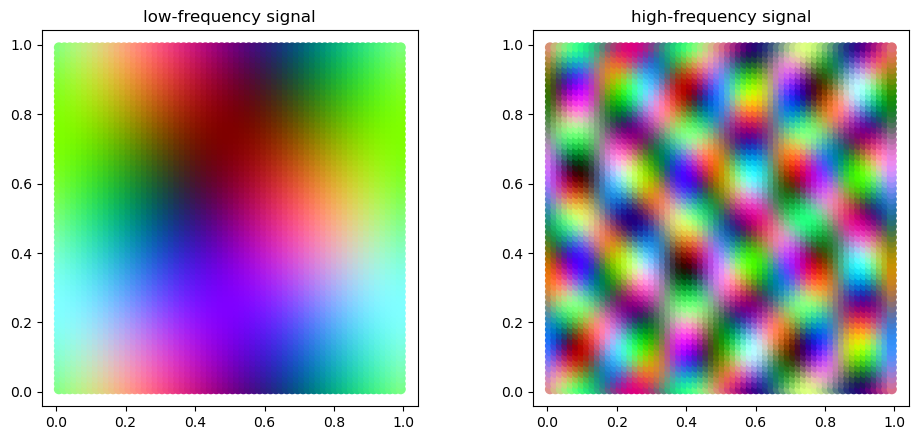

In [37]:
coords = SquareSampler(stratified=True, add_noise=False).sample(64).to(device)
lad    = torch.zeros(coords.shape[0], device=device)

d = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=1e-3)

low_idx = torch.tensor([
    [ 0,  0, 0],
    [ 1,  0, 1],
    [ 0, -1, 2],
    [-1,  1, 0],
])
high_idx = torch.tensor([
    [ 4,  3, 0],
    [-3,  4, 1],
    [ 5, -2, 2],
    [-4, -4, 0],
])

low_signal  = d.get_atoms(coords, low_idx.to(device)).sum(0)            # (N, C)
high_signal = d.get_atoms(coords, high_idx.to(device)).sum(0)

# Quick visualisation
def to_rgb(s):
    s = s.detach().cpu().float().numpy()
    out = np.zeros_like(s)
    for c in range(s.shape[-1]):
        lo, hi = s[:, c].min(), s[:, c].max()
        out[:, c] = (s[:, c] - lo) / (hi - lo + 1e-8)
    return out

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, title, sig in zip(axes, ['low-frequency signal', 'high-frequency signal'], [low_signal, high_signal]):
    ax.scatter(coords[:, 0].cpu(), coords[:, 1].cpu(), c=to_rgb(sig), s=40)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout(); plt.show()

100%|██████████| 600/600 [00:03<00:00, 188.00it/s]


Captured energy (mean ± std over 600 MC draws, tail_prob=1e-06):
  low-freq  : 0.1664 ± 0.0000
  high-freq : 5.1497e-04 ± 0.0000e+00
  ratio     : 323×  (expected ≫ 1: prior favours low-freq)


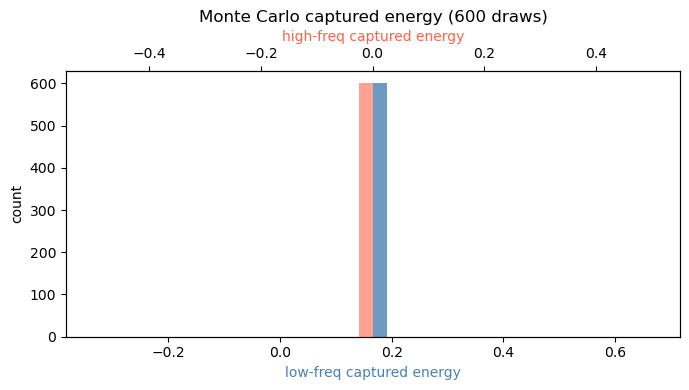

In [38]:
all_signals = torch.stack([low_signal, high_signal])    # (2, N, C)
n_draws     = 600
tail_n      = 64
# tail_probability needs to be small enough that the high-freq atoms (shell 4–5,
# per-atom PMF ≈ 3e-5) sit inside the *deterministic* stratum.  With
# tail_probability=1e-6 every atom up to shell 6 is computed exactly, so the MC
# tail only handles the truly negligible asymptotic tail.
tail_prob   = 1e-6

estimates = []
torch.manual_seed(0)
for _ in tqdm(range(n_draws)):
    e = d.monte_carlo_captured_energy(
        coords=coords, logabsdet=lad, values=all_signals,
        num_tail_samples=tail_n, tail_probability=tail_prob,
    )
    estimates.append(e.detach().cpu())
estimates = torch.stack(estimates)        # (n_draws, 2)

mean_low, mean_high = estimates.mean(0).tolist()
std_low,  std_high  = estimates.std(0).tolist()
print(f'Captured energy (mean ± std over {n_draws} MC draws, tail_prob={tail_prob:g}):')
print(f'  low-freq  : {mean_low:.4f} ± {std_low:.4f}')
print(f'  high-freq : {mean_high:.4e} ± {std_high:.4e}')
print(f'  ratio     : {mean_low/max(mean_high, 1e-12):.0f}×  (expected ≫ 1: prior favours low-freq)')

fig, ax = plt.subplots(figsize=(7, 4))
# Two separate histograms because low- and high-freq energies live on very
# different scales.
ax.hist(estimates[:, 0].numpy(), bins=40, color='steelblue', alpha=0.8, label='low-freq')
ax2 = ax.twiny()
ax2.hist(estimates[:, 1].numpy(), bins=40, color='tomato',    alpha=0.6, label='high-freq')
ax.set_xlabel('low-freq captured energy', color='steelblue')
ax2.set_xlabel('high-freq captured energy', color='tomato')
ax.set_ylabel('count')
ax.set_title(f'Monte Carlo captured energy ({n_draws} draws)')
plt.tight_layout(); plt.show()

### Closed-form check

For pure-Fourier test signals the captured energy can also be computed in closed form,
$$E[f] \;=\; \sum_k \nu(k)\,\bigl|\langle f, \phi_k\rangle\bigr|^2,$$
by summing over a sufficiently large truncated set. We compare the MC mean against this reference.

In [39]:
from infidictionary.utils import pairwise_inner_product

ref_idx = d.get_truncated_indices(20).to(device)              # all atoms with |k|_∞ ≤ 19, C=3
ref_atoms = d.get_atoms(coords, ref_idx)
ref_pmfs  = d.get_index_pmfs(ref_idx).to(device)
ref_coeff = pairwise_inner_product(all_signals, ref_atoms, lad)   # (2, A)
ref_energy = (ref_coeff.pow(2) * ref_pmfs[None, :]).sum(-1).cpu()

print(f"reference (truncated sum, |k|_∞ ≤ 19): low={ref_energy[0]:.4f}, high={ref_energy[1]:.4f}")
print(f"MC mean                              : low={mean_low:.4f}, high={mean_high:.4f}")
print(f"|MC - reference| / reference         : low={abs(mean_low-ref_energy[0].item())/ref_energy[0].item():.2%}, "
      f"high={abs(mean_high-ref_energy[1].item())/ref_energy[1].item():.2%}")

reference (truncated sum, |k|_∞ ≤ 19): low=0.1664, high=0.0005
MC mean                              : low=0.1664, high=0.0005
|MC - reference| / reference         : low=0.00%, high=0.00%
